# Clinical Feature Selection Benchmark
## Breast Cancer Wisconsin Diagnostic Dataset

This notebook demonstrates a single-dataset workflow for comparing feature selection methods under a clinically guided relevance layer.

### Goals
- Compare LASSO, ANOVA, mRMR, and Random Forest feature importance
- Train Logistic Regression, Random Forest, and XGBoost
- Measure predictive performance
- Measure feature stability
- Apply a simple clinical relevance filter

### Note
This notebook is a sample implementation for one dataset only. It is designed to validate the workflow before scaling to multiple diseases.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Scikit-learn utilities
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

# 2. Dataset Loading and Initial Exploration

This section loads the **Breast Cancer Wisconsin Diagnostic Dataset** from scikit-learn and performs an initial exploration.

Understanding the dataset helps us:

- identify the number of observations and features
- understand the prediction target
- inspect feature names
- verify data quality
- check whether missing values exist
- examine class distribution

A clear understanding of the dataset is essential before preprocessing and model development.

In [3]:
# Load dataset
cancer = load_breast_cancer()

# Create feature dataframe
X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Create target series
y = pd.Series(
    cancer.target,
    name="target"
)


In [4]:

# Combine for easier exploration
df = pd.concat([X, y], axis=1)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Dataset Dimensions

The first step is to determine the size of the dataset.

We inspect:

- Number of samples (patients)
- Number of predictor variables (features)
- Number of target classes

In [5]:
print(f"Number of Samples : {X.shape[0]}")
print(f"Number of Features: {X.shape[1]}")
print(f"Target Classes    : {len(cancer.target_names)}")

Number of Samples : 569
Number of Features: 30
Target Classes    : 2


## Feature Names

Machine learning models use numerical values, but researchers must understand what those variables represent.

Listing all feature names allows us to identify the clinical measurements available in the dataset.

In [6]:
feature_df = pd.DataFrame({
    "Feature Number": range(1, len(cancer.feature_names)+1),
    "Feature Name": cancer.feature_names
})

feature_df

,Feature Number,Feature Name
0,1,mean radius
1,2,mean texture
2,3,mean perimeter
3,4,mean area
4,5,mean smoothness
5,6,mean compactness
6,7,mean concavity
7,8,mean concave points
8,9,mean symmetry
9,10,mean fractal dimension


## Target Classes

The prediction target indicates whether a tumour is:

- Malignant
- Benign

Understanding the target labels is important because this is a binary classification problem.

In [7]:
print("Target Labels")

for i, label in enumerate(cancer.target_names):
    print(f"{i} : {label}")

Target Labels
0 : malignant
1 : benign


## Display the First Five Records

Viewing the first few observations helps verify that the dataset has been loaded correctly and provides an overview of the feature values.

In [8]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Dataset Information

The `info()` function provides:

- number of observations
- feature data types
- non-null values

This helps identify potential missing values and confirms whether the variables are stored in the expected format.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## Statistical Summary

Descriptive statistics provide an overview of the numerical distribution of each feature.

These statistics include:

- mean
- standard deviation
- minimum
- maximum
- quartiles

They help identify scale differences and potential outliers before preprocessing.

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Missing Value Analysis

Clinical datasets frequently contain missing values.

Before proceeding to preprocessing, we verify whether any values are missing.

In [11]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Feature": missing.index,
    "Missing Values": missing.values
})

missing_df.head()

,Feature,Missing Values
0,mean radius,0
1,mean texture,0
2,mean perimeter,0
3,mean area,0
4,mean smoothness,0


In [12]:
print("Total Missing Values")

print(df.isnull().sum().sum())

Total Missing Values
0


## Class Distribution

Finally, we inspect the number of observations belonging to each class.

A balanced dataset generally leads to more reliable model evaluation, whereas severe class imbalance may require additional preprocessing techniques.

In [13]:
class_distribution = y.value_counts().rename_axis("Class").reset_index(name="Count")

class_distribution["Class"] = class_distribution["Class"].map({
    0: "Malignant",
    1: "Benign"
})

class_distribution

,Class,Count
0,Benign,357
1,Malignant,212


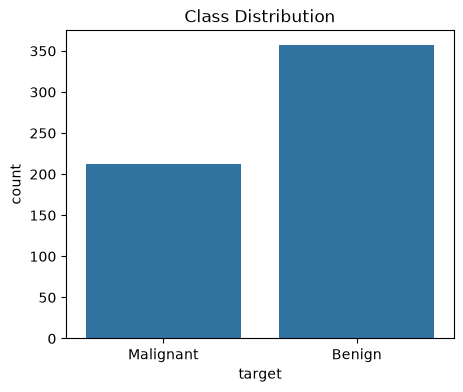

In [14]:
plt.figure(figsize=(5,4))

sns.countplot(
    x=y,
)

plt.xticks(
    [0,1],
    ["Malignant","Benign"]
)

plt.title("Class Distribution")

plt.show()

# 3. Data Preprocessing

## Train-Test Split

The dataset is divided into:

- **Training Set (80%)**: Used for feature selection and model training.
- **Testing Set (20%)**: Used only for final model evaluation.

A stratified split is used to preserve the proportion of malignant and benign cases in both subsets.

In [15]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed Successfully!\n")

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"Training Features: {X_train.shape[1]}")
print(f"Testing Features : {X_test.shape[1]}")

Train-Test Split Completed Successfully!

Training Samples : 455
Testing Samples  : 114
Training Features: 30
Testing Features : 30


### Why Stratified Splitting?

The Breast Cancer dataset contains two classes:

- Malignant
- Benign

A stratified split ensures that both classes are represented in approximately the same proportion in the training and testing datasets.

This produces a more reliable evaluation of model performance.

In [16]:
# Verify Class Distribution in Train and Test Sets

train_distribution = (
    y_train.value_counts(normalize=True)
    .rename_axis("Class")
    .reset_index(name="Proportion")
)

train_distribution["Class"] = train_distribution["Class"].map({
    0: "Malignant",
    1: "Benign"
})

test_distribution = (
    y_test.value_counts(normalize=True)
    .rename_axis("Class")
    .reset_index(name="Proportion")
)

test_distribution["Class"] = test_distribution["Class"].map({
    0: "Malignant",
    1: "Benign"
})

print("Training Class Distribution")
display(train_distribution)

print("\nTesting Class Distribution")
display(test_distribution)

Training Class Distribution


,Class,Proportion
0,Benign,0.626374
1,Malignant,0.373626



Testing Class Distribution


,Class,Proportion
0,Benign,0.631579
1,Malignant,0.368421


## Feature Scaling

The Breast Cancer dataset contains measurements with different numerical ranges.

For example:

- Mean Radius
- Mean Area
- Worst Perimeter

These variables have different scales.

Many machine learning algorithms, including Logistic Regression, LASSO, and Support Vector Machines, perform better when features are standardized.

Standardization transforms each feature so that:

- Mean = 0
- Standard Deviation = 1

To avoid data leakage, the scaler is fitted **only on the training data**, and the same transformation is applied to the testing data.

In [17]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

print(f"Training Shape : {X_train_scaled.shape}")
print(f"Testing Shape  : {X_test_scaled.shape}")

Feature Scaling Completed Successfully!
Training Shape : (455, 30)
Testing Shape  : (114, 30)


### Preventing Data Leakage

The scaler learns the mean and standard deviation of the training dataset.

If the scaler were fitted on the entire dataset before splitting, information from the testing data would leak into the training process.

Therefore:

- `fit_transform()` is applied only to the training data.
- `transform()` is applied to the testing data using the statistics learned from the training set.

This ensures a fair and unbiased evaluation.

In [18]:
# Convert scaled arrays back to DataFrames for easier exploration

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

print("Scaled DataFrames Created Successfully!")

Scaled DataFrames Created Successfully!


## Interpretation

The dataset has now been successfully preprocessed.

The key preprocessing steps include:

- Stratified train-test splitting
- Feature standardization
- Prevention of data leakage
- Preservation of feature names after scaling

The processed training dataset is now ready for feature selection methods, while the testing dataset will remain untouched until model evaluation.

# 4. Feature Selection

Feature selection aims to identify the most informative variables while removing redundant or less useful features.

Benefits of feature selection include:

- Reduced model complexity
- Improved interpretability
- Faster training
- Reduced overfitting
- Better generalization

In this notebook, four feature selection methods are compared:

1. ANOVA F-test
2. LASSO
3. mRMR
4. Random Forest Feature Importance

Each method selects the **top 10 features**, which are then used for model training and evaluation.

## 4.1 ANOVA Feature Selection

### Why ANOVA?

The Analysis of Variance (ANOVA) F-test is a **filter-based feature selection method**.

It evaluates each feature independently by measuring how well it separates the target classes.

Features with higher F-scores have greater discriminatory power and are considered more informative for classification.

Since ANOVA evaluates each feature individually, it is computationally efficient and serves as a useful baseline for comparison.

In [19]:
# Number of features to select
k = 10

# Initialize ANOVA selector
anova_selector = SelectKBest(
    score_func=f_classif,
    k=k
)

# Fit only on training data
anova_selector.fit(X_train_scaled, y_train)

# Transform training and testing sets
X_train_anova = anova_selector.transform(X_train_scaled)
X_test_anova = anova_selector.transform(X_test_scaled)

In [20]:
selected_mask = anova_selector.get_support()

anova_features = X_train_scaled.columns[selected_mask]

anova_scores = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "F Score": anova_selector.scores_
})

anova_scores = anova_scores.sort_values(
    by="F Score",
    ascending=False
)

anova_scores.head(10)

,Feature,F Score
27,worst concave points,795.223341
22,worst perimeter,719.598823
7,mean concave points,703.364031
20,worst radius,687.430367
2,mean perimeter,565.485755
23,worst area,541.713694
0,mean radius,523.613907
3,mean area,469.516453
6,mean concavity,416.374874
26,worst concavity,365.747389


### Top Features Selected by ANOVA

The following table lists the ten highest-ranked features according to the ANOVA F-test.

Higher F-scores indicate stronger statistical association with the target variable.

In [21]:
print("Selected Features\n")

for feature in anova_features:
    print(f"• {feature}")

Selected Features

• mean radius
• mean perimeter
• mean area
• mean concavity
• mean concave points
• worst radius
• worst perimeter
• worst area
• worst concavity
• worst concave points


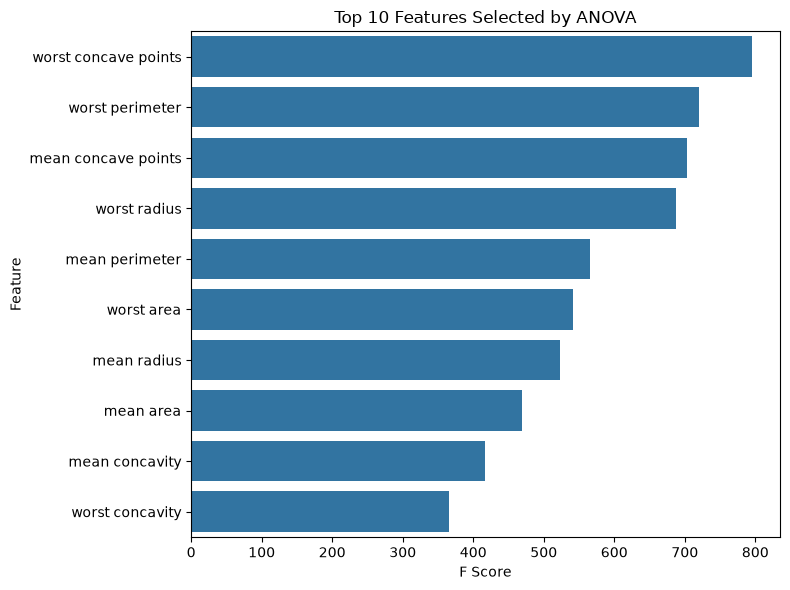

In [22]:
plt.figure(figsize=(8,6))

top10 = anova_scores.head(10)

sns.barplot(
    data=top10,
    y="Feature",
    x="F Score"
)

plt.title("Top 10 Features Selected by ANOVA")

plt.tight_layout()

plt.show()

### Interpretation

The ANOVA F-test ranked the features according to their individual statistical association with the target variable.

The selected features represent the strongest independent predictors of breast cancer diagnosis according to this filter-based approach.

These features will be used as inputs for the predictive models in later sections, allowing comparison with other feature selection methods.

## 4.2 Minimum Redundancy Maximum Relevance (mRMR)

### Why mRMR?

Unlike ANOVA, which evaluates each feature independently, **Minimum Redundancy Maximum Relevance (mRMR)** considers both the relationship between each feature and the target variable, as well as the redundancy among the selected features.

The objective is to identify features that:

- have high predictive relevance
- contribute unique information
- reduce redundancy within the final feature subset

This makes mRMR particularly suitable for biomedical datasets, where multiple clinical variables are often highly correlated.

In [23]:
# import

from mrmr import mrmr_classif

In [24]:
# Number of features
k = 10

# Perform mRMR feature selection
mrmr_features = mrmr_classif(
    X=X_train_scaled,
    y=y_train,
    K=k
)

print("Selected Features using mRMR:\n")

for feature in mrmr_features:
    print(f"• {feature}")

100%|██████████| 10/10 [00:00<00:00, 35.56it/s]

Selected Features using mRMR:

• worst concave points
• worst perimeter
• mean concave points
• worst radius
• mean perimeter
• worst area
• mean radius
• worst concavity
• mean concavity
• mean area


In [25]:
mrmr_df = pd.DataFrame({
    "Rank": range(1, len(mrmr_features)+1),
    "Feature": mrmr_features
})

mrmr_df

,Rank,Feature
0,1,worst concave points
1,2,worst perimeter
2,3,mean concave points
3,4,worst radius
4,5,mean perimeter
5,6,worst area
6,7,mean radius
7,8,worst concavity
8,9,mean concavity
9,10,mean area


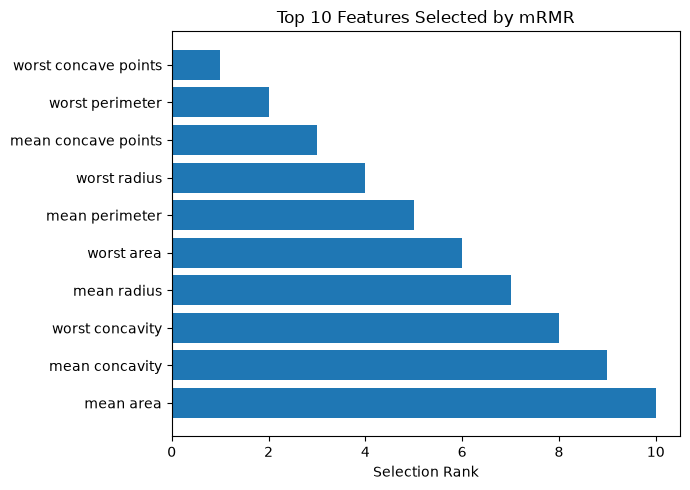

In [26]:
plt.figure(figsize=(7,5))

plt.barh(
    mrmr_df["Feature"],
    mrmr_df["Rank"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Features Selected by mRMR")

plt.xlabel("Selection Rank")

plt.tight_layout()

plt.show()

In [27]:
# comparision of ANOVA and mRMR selected features

comparison_df = pd.DataFrame({
    "ANOVA": list(anova_features),
    "mRMR": mrmr_features
})

comparison_df

,ANOVA,mRMR
0,mean radius,worst concave points
1,mean perimeter,worst perimeter
2,mean area,mean concave points
3,mean concavity,worst radius
4,mean concave points,mean perimeter
5,worst radius,worst area
6,worst perimeter,mean radius
7,worst area,worst concavity
8,worst concavity,mean concavity
9,worst concave points,mean area


### Interpretation

The mRMR algorithm selected ten features that maximize predictive relevance while minimizing redundancy among the selected variables.

Compared with ANOVA, the selected feature subset may contain fewer highly correlated variables, resulting in a more diverse and informative representation of the dataset.

These selected features will be used during model training and compared with the feature subsets produced by the other feature selection methods.

## 4.3 Random Forest Feature Importance

Random Forest is an ensemble learning algorithm that builds multiple decision trees.

During training, the model estimates how much each feature contributes to improving classification decisions.

Features with higher importance scores contribute more to reducing prediction error and are considered more informative.

Unlike filter-based methods, Random Forest performs feature selection as part of the model training process, making it an **embedded feature selection method**.

In [28]:
# Number of selected features
k = 10

# Initialize Random Forest
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train only on the training data
rf_selector.fit(X_train_scaled, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [29]:
# Extract feature importances

feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": rf_selector.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


In [30]:
# Select top 10 features

rf_features = feature_importance.head(k)["Feature"].tolist()

print("Top 10 Features Selected by Random Forest:\n")

for feature in rf_features:
    print(f"• {feature}")

Top 10 Features Selected by Random Forest:

• worst area
• worst concave points
• worst radius
• mean concave points
• worst perimeter
• mean perimeter
• mean radius
• mean concavity
• mean area
• worst concavity


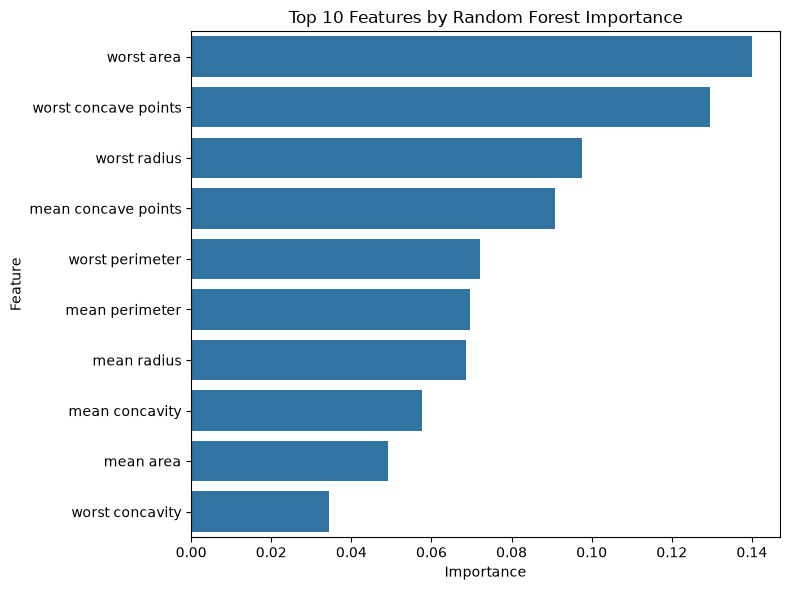

In [31]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    y="Feature",
    x="Importance"
)

plt.title("Top 10 Features by Random Forest Importance")

plt.tight_layout()

plt.show()

### Interpretation

Random Forest ranked the predictor variables according to their contribution to reducing classification error during tree construction.

Unlike ANOVA and mRMR, which evaluate statistical relationships between features and the target variable, Random Forest captures non-linear interactions and complex decision boundaries.

The selected feature subset represents the variables that contributed most to the predictive performance of the ensemble model.

In [32]:
# store selected feature sets

X_train_rf = X_train_scaled[rf_features]

X_test_rf = X_test_scaled[rf_features]

In [33]:
# comparision of ANOVA, mRMR and Random Forest selected features

comparison_df = pd.DataFrame({
    "ANOVA": list(anova_features),
    "mRMR": mrmr_features,
    "Random Forest": rf_features
})

comparison_df

,ANOVA,mRMR,Random Forest
0,mean radius,worst concave points,worst area
1,mean perimeter,worst perimeter,worst concave points
2,mean area,mean concave points,worst radius
3,mean concavity,worst radius,mean concave points
4,mean concave points,mean perimeter,worst perimeter
5,worst radius,worst area,mean perimeter
6,worst perimeter,mean radius,mean radius
7,worst area,worst concavity,mean concavity
8,worst concavity,mean concavity,mean area
9,worst concave points,mean area,worst concavity


## 4.4 LASSO Feature Selection

### Why LASSO?

LASSO (Least Absolute Shrinkage and Selection Operator) is an embedded feature selection method that performs feature selection during model training.

Unlike filter-based methods, LASSO applies **L1 regularization**, which shrinks the coefficients of less important features toward zero.

Features with coefficients equal to zero are effectively excluded from the model.

Advantages of LASSO include:

- Automatic feature selection
- Reduced model complexity
- Improved interpretability
- Reduced risk of overfitting

LASSO is widely used in biomedical and clinical prediction studies because it produces compact and interpretable models.

In [34]:
# Initialize Logistic Regression with L1 penalty (LASSO)
lasso_selector = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    random_state=42,
    max_iter=1000
)

# Fit only on training data
lasso_selector.fit(X_train_scaled, y_train)

print("LASSO model trained successfully!")

LASSO model trained successfully!


In [35]:
# Extract coefficients

lasso_coefficients = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": lasso_selector.coef_[0]
})

In [36]:
# Absolute coefficient values for ranking

lasso_coefficients["Absolute Coefficient"] = (
    lasso_coefficients["Coefficient"].abs()
)

In [37]:
# Sort descending

lasso_coefficients = lasso_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

lasso_coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
20,worst radius,-2.122532,2.122532
27,worst concave points,-0.943057,0.943057
21,worst texture,-0.575617,0.575617
7,mean concave points,-0.500713,0.500713
10,radius error,-0.431542,0.431542
24,worst smoothness,-0.206336,0.206336
28,worst symmetry,-0.173980,0.173980
1,mean texture,-0.049188,0.049188
8,mean symmetry,0.000000,0.000000
4,mean smoothness,0.000000,0.000000


In [38]:
lasso_features = (
    lasso_coefficients
    .head(10)["Feature"]
    .tolist()
)

print("Top 10 Features Selected by LASSO:\n")

for feature in lasso_features:
    print(f"• {feature}")

Top 10 Features Selected by LASSO:

• worst radius
• worst concave points
• worst texture
• mean concave points
• radius error
• worst smoothness
• worst symmetry
• mean texture
• mean symmetry
• mean smoothness


In [39]:
# Create feature subsets

X_train_lasso = X_train_scaled[lasso_features]

X_test_lasso = X_test_scaled[lasso_features]

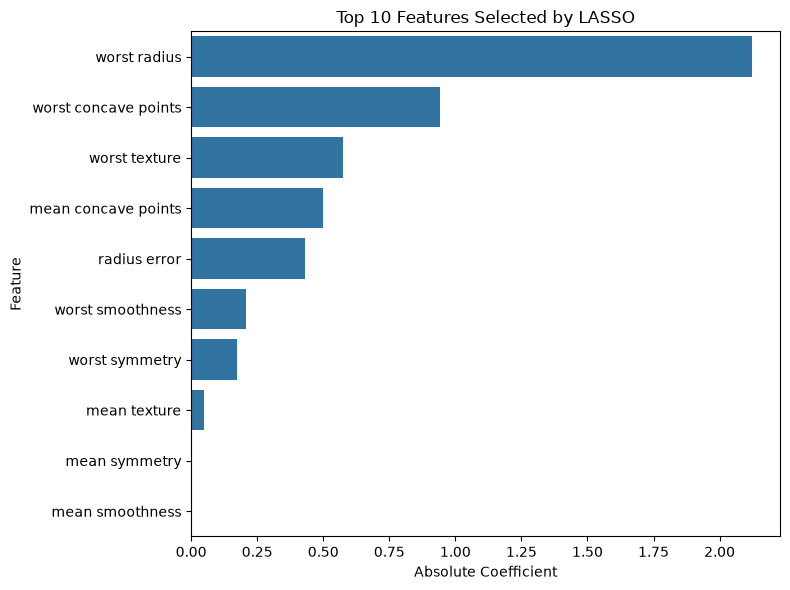

In [40]:
# Visualize coefficients

plt.figure(figsize=(8,6))

sns.barplot(
    data=lasso_coefficients.head(10),
    y="Feature",
    x="Absolute Coefficient"
)

plt.title("Top 10 Features Selected by LASSO")

plt.xlabel("Absolute Coefficient")

plt.tight_layout()

plt.show()

In [41]:
# comparision of ANOVA, mRMR, Random Forest and LASSO selected features

comparison_df = pd.DataFrame({
    "ANOVA": list(anova_features),
    "mRMR": mrmr_features,
    "Random Forest": rf_features,
    "LASSO": lasso_features
})

comparison_df

,ANOVA,mRMR,Random Forest,LASSO
0,mean radius,worst concave points,worst area,worst radius
1,mean perimeter,worst perimeter,worst concave points,worst concave points
2,mean area,mean concave points,worst radius,worst texture
3,mean concavity,worst radius,mean concave points,mean concave points
4,mean concave points,mean perimeter,worst perimeter,radius error
5,worst radius,worst area,mean perimeter,worst smoothness
6,worst perimeter,mean radius,mean radius,worst symmetry
7,worst area,worst concavity,mean concavity,mean texture
8,worst concavity,mean concavity,mean area,mean symmetry
9,worst concave points,mean area,worst concavity,mean smoothness


### Interpretation

LASSO selected features by shrinking the coefficients of less informative variables toward zero through L1 regularization.

Unlike ANOVA and mRMR, which evaluate features before model training, LASSO performs feature selection as part of the model fitting process.

The selected feature subset represents the variables with the strongest contribution to the classification model after regularization.

These features will be used for training and evaluating predictive models in the next section.

## 4.5 Boruta Feature Selection

### Why Boruta?

Boruta is a wrapper-based feature selection algorithm that identifies **all relevant features** rather than only a minimal subset.

Unlike filter methods, Boruta repeatedly trains a Random Forest classifier and compares the importance of real features with randomly shuffled copies called **shadow features**.

A feature is considered important only if it consistently performs better than the best shadow feature.

This iterative process makes Boruta particularly suitable for biomedical datasets, where preserving clinically relevant variables is often more important than selecting the smallest possible feature subset.

Boruta is widely used in genomics, radiomics, biomarker discovery, and clinical machine learning because of its robustness and interpretability.

In [42]:
from boruta import BorutaPy

from sklearn.ensemble import RandomForestClassifier

### Initialize the Boruta Algorithm

Boruta requires a tree-based estimator to evaluate feature importance.

In this study, a Random Forest classifier is used as the underlying estimator.

To ensure reproducibility, a fixed random seed is used.

In [43]:
# Random Forest estimator used by Boruta
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Initialize Boruta
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    random_state=42,
    verbose=0
)

# Fit Boruta on training data only
boruta_selector.fit(
    X_train_scaled.values,
    y_train.values
)

print("Boruta feature selection completed successfully!")

Boruta feature selection completed successfully!


In [44]:
# Extract confirmed features

boruta_features = X_train_scaled.columns[
    boruta_selector.support_
].tolist()

print(f"Number of Confirmed Features: {len(boruta_features)}\n")

for feature in boruta_features:
    print(f"• {feature}")

Number of Confirmed Features: 23

• mean radius
• mean texture
• mean perimeter
• mean area
• mean smoothness
• mean compactness
• mean concavity
• mean concave points
• radius error
• perimeter error
• area error
• concavity error
• concave points error
• worst radius
• worst texture
• worst perimeter
• worst area
• worst smoothness
• worst compactness
• worst concavity
• worst concave points
• worst symmetry
• worst fractal dimension


In [45]:
# If more than 10 confirmed features are selected,
# we are going to rank them using Boruta's importance ranking.

if len(boruta_features) > 10:

    ranking_df = pd.DataFrame({
        "Feature": X_train_scaled.columns,
        "Rank": boruta_selector.ranking_
    })

    ranking_df = ranking_df[
        ranking_df["Feature"].isin(boruta_features)
    ].sort_values("Rank")

    boruta_features = ranking_df.head(10)["Feature"].tolist()

print("\nFinal Features Used in Benchmark:\n")

for feature in boruta_features:
    print(f"• {feature}")


Final Features Used in Benchmark:

• mean radius
• mean texture
• mean perimeter
• mean area
• mean smoothness
• mean compactness
• mean concavity
• mean concave points
• radius error
• perimeter error


In [46]:
# creating feature subsets for training and testing

X_train_boruta = X_train_scaled[boruta_features]

X_test_boruta = X_test_scaled[boruta_features]

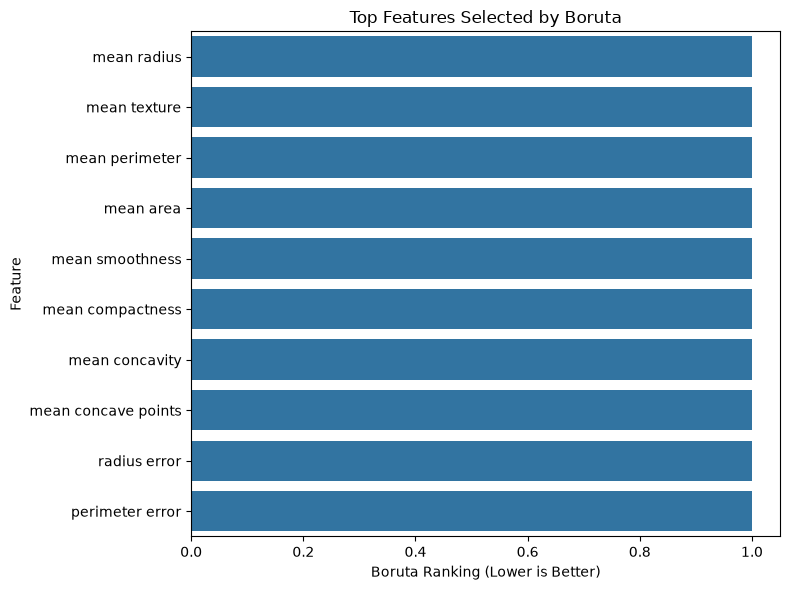

In [47]:
# visualization of Boruta's feature importance ranking

ranking_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Rank": boruta_selector.ranking_
})

ranking_df = ranking_df.sort_values("Rank").head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=ranking_df,
    y="Feature",
    x="Rank"
)

plt.title("Top Features Selected by Boruta")

plt.xlabel("Boruta Ranking (Lower is Better)")

plt.tight_layout()

plt.show()

In [48]:
# final comparision of ANOVA, mRMR, Random Forest, LASSO and Boruta selected features

comparison_df = pd.DataFrame({
    "ANOVA": list(anova_features),
    "mRMR": mrmr_features,
    "Random Forest": rf_features,
    "LASSO": lasso_features,
    "Boruta": boruta_features
})

comparison_df

,ANOVA,mRMR,Random Forest,LASSO,Boruta
0,mean radius,worst concave points,worst area,worst radius,mean radius
1,mean perimeter,worst perimeter,worst concave points,worst concave points,mean texture
2,mean area,mean concave points,worst radius,worst texture,mean perimeter
3,mean concavity,worst radius,mean concave points,mean concave points,mean area
4,mean concave points,mean perimeter,worst perimeter,radius error,mean smoothness
5,worst radius,worst area,mean perimeter,worst smoothness,mean compactness
6,worst perimeter,mean radius,mean radius,worst symmetry,mean concavity
7,worst area,worst concavity,mean concavity,mean texture,mean concave points
8,worst concavity,mean concavity,mean area,mean symmetry,radius error
9,worst concave points,mean area,worst concavity,mean smoothness,perimeter error


### Interpretation

Boruta identified features by repeatedly comparing the importance of original variables against randomly generated shadow features using a Random Forest classifier.

Unlike filter-based methods, Boruta attempts to identify **all relevant features** rather than simply ranking variables based on statistical association or model coefficients.

For consistency in this benchmark, the final comparison uses the top ten confirmed features returned by the Boruta algorithm.

Boruta provides a robust wrapper-based perspective on feature relevance and complements the filter and embedded methods evaluated in this study.

# 5. Model Training and Performance Evaluation

## Why model training?

Feature selection identifies informative variables, but it does not determine how well those features perform in a predictive model.

Therefore, the selected feature subsets are used to train multiple machine learning algorithms.

Using the same predictive models across all feature selection methods ensures a fair comparison of their effectiveness.

Three classification models are evaluated:

- Logistic Regression
- Random Forest
- XGBoost

Each model is trained using the feature subsets generated by the five feature selection methods.

In [49]:
# feature dictionary

feature_sets = {
    "ANOVA": (
        X_train_scaled[anova_features],
        X_test_scaled[anova_features]
    ),

    "mRMR": (
        X_train_scaled[mrmr_features],
        X_test_scaled[mrmr_features]
    ),

    "Random Forest": (
        X_train_scaled[rf_features],
        X_test_scaled[rf_features]
    ),

    "LASSO": (
        X_train_scaled[lasso_features],
        X_test_scaled[lasso_features]
    ),

    "Boruta": (
        X_train_scaled[boruta_features],
        X_test_scaled[boruta_features]
    )
}

In [50]:
# model dictionary

models = {

    "Logistic Regression":

    LogisticRegression(
        random_state=42
    ),

    "Random Forest":

    RandomForestClassifier(
        random_state=42
    ),

    "XGBoost":

    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

}

## 5.2 Baseline Experiment: Logistic Regression with ANOVA Features

Before automating all model training experiments, it is useful to understand the workflow using a single example.

In this section, Logistic Regression is trained using the features selected by the ANOVA feature selection method.

This baseline experiment demonstrates the standard machine learning workflow:

1. Select a feature subset.
2. Train the model using the training data.
3. Predict the labels of the unseen testing data.
4. Evaluate model performance.

Once this workflow is validated, the same process will be automated for all feature selection methods and machine learning models.

In [51]:
    # Select ANOVA feature subset

X_train_current, X_test_current = feature_sets["ANOVA"]

print("Training Samples :", X_train_current.shape)
print("Testing Samples  :", X_test_current.shape)

Training Samples : (455, 10)
Testing Samples  : (114, 10)


In [52]:
# Select Logistic Regression model

model = models["Logistic Regression"]

print(model)

LogisticRegression(random_state=42)


In [53]:
# Train the model

model.fit(
    X_train_current,
    y_train
)

print("Model training completed successfully!")

Model training completed successfully!


### Model Training

The selected model is trained using the training dataset.

During training, the algorithm learns the relationship between the selected features and the target variable.

The testing dataset is **not** used during training.

Keeping the testing data completely unseen prevents data leakage and provides an unbiased estimate of model performance.

In [54]:
# Predict class labels

y_pred = model.predict(X_test_current)

print(y_pred[:10])

[0 1 0 1 0 1 1 0 0 0]


In [55]:
# Predict class probabilities

y_prob = model.predict_proba(X_test_current)[:, 1]

print(y_prob[:10])

[1.16818013e-05 9.99212901e-01 3.83712788e-01 5.11177676e-01
 4.86375730e-06 9.37284043e-01 9.99525420e-01 1.02834875e-04
 1.87784278e-03 3.77119542e-07]


### Prediction Probabilities

In addition to predicting class labels, many classification models can estimate the probability that an observation belongs to the positive class.

These probabilities are required for threshold-independent evaluation metrics such as the Receiver Operating Characteristic (ROC) curve and the Area Under the ROC Curve (ROC-AUC).

Probability estimates provide richer information than binary class predictions and are commonly used in clinical decision support systems.

## 5.3 Model Evaluation

Model evaluation measures how well the trained classifier predicts unseen data.

Multiple evaluation metrics are used because no single metric completely describes model performance.

In clinical prediction studies, relying only on accuracy may be misleading, particularly when class distributions are imbalanced.

Therefore, the following evaluation metrics are considered:

- Accuracy
- Precision
- Recall (Sensitivity)
- F1-score
- ROC-AUC
- Confusion Matrix

These metrics provide complementary perspectives on predictive performance.

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [57]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

In [58]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9474
Precision: 0.9714
Recall   : 0.9444
F1 Score : 0.9577
ROC-AUC  : 0.9921


### Interpretation

Each evaluation metric measures a different aspect of classification performance.

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many predicted positive cases are truly positive.
- **Recall (Sensitivity)** measures how many actual positive cases are correctly identified.
- **F1-score** provides a balance between precision and recall.
- **ROC-AUC** evaluates the model's ability to distinguish between classes across all classification thresholds.

Together, these metrics provide a comprehensive assessment of predictive performance.

In [59]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [60]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm


array([[40,  2],
       [ 4, 68]])

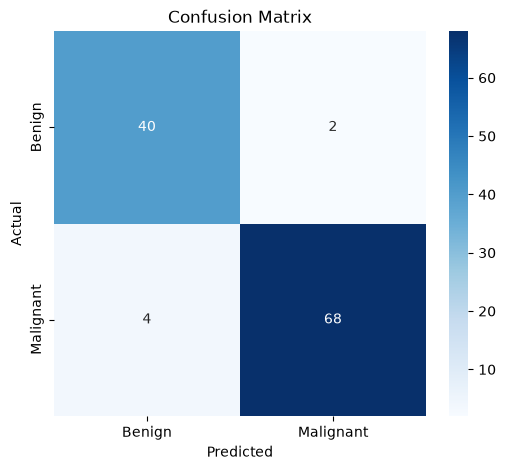

In [61]:
# Visualize Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### Interpretation

The confusion matrix summarizes the classification outcomes.

- **True Positives (TP):** Correctly predicted positive cases.
- **True Negatives (TN):** Correctly predicted negative cases.
- **False Positives (FP):** Negative cases incorrectly predicted as positive.
- **False Negatives (FN):** Positive cases incorrectly predicted as negative.

In clinical applications, minimizing false negatives is particularly important because failing to identify patients with disease may delay diagnosis and treatment.

## 5.4 Automating Model Training and Evaluation

After validating the workflow using a single baseline experiment, the same process is automated for every combination of feature selection method and machine learning model.

Each experiment follows the same sequence:

1. Select a feature subset.
2. Train a machine learning model.
3. Predict on the testing dataset.
4. Calculate evaluation metrics.
5. Store the results.

This ensures that every experiment is performed consistently and reproducibly.

In [62]:
results = []

for fs_method, (X_train_fs, X_test_fs) in feature_sets.items():

    for model_name, model in models.items():

        print(f"{fs_method} + {model_name}")

ANOVA + Logistic Regression
ANOVA + Random Forest
ANOVA + XGBoost
mRMR + Logistic Regression
mRMR + Random Forest
mRMR + XGBoost
Random Forest + Logistic Regression
Random Forest + Random Forest
Random Forest + XGBoost
LASSO + Logistic Regression
LASSO + Random Forest
LASSO + XGBoost
Boruta + Logistic Regression
Boruta + Random Forest
Boruta + XGBoost


## 5.5 Execute All Model Training Experiments

This section automates the complete machine learning workflow for every combination of feature selection method and classification model.

For each experiment, the following steps are performed:

1. Train the selected model.
2. Predict class labels for the testing dataset.
3. Predict class probabilities.
4. Compute evaluation metrics.
5. Store the results.

The evaluation metrics collected include:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The results are stored in a list and later converted into a structured table for comparison.

In [63]:
# ============================================
# Run All Experiments
# ============================================

results = []

for fs_method, (X_train_fs, X_test_fs) in feature_sets.items():

    for model_name, model in models.items():

        # ----------------------------
        # Train model
        # ----------------------------
        model.fit(X_train_fs, y_train)

        # ----------------------------
        # Predictions
        # ----------------------------
        y_pred = model.predict(X_test_fs)

        y_prob = model.predict_proba(X_test_fs)[:, 1]

        # ----------------------------
        # Evaluation Metrics
        # ----------------------------
        accuracy = accuracy_score(y_test, y_pred)

        precision = precision_score(y_test, y_pred)

        recall = recall_score(y_test, y_pred)

        f1 = f1_score(y_test, y_pred)

        roc_auc = roc_auc_score(y_test, y_prob)

        # ----------------------------
        # Store Results
        # ----------------------------
        results.append({

            "Feature Selection": fs_method,

            "Model": model_name,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1 Score": f1,

            "ROC-AUC": roc_auc

        })

print("All experiments completed successfully!")

All experiments completed successfully!


In [64]:
results_df = pd.DataFrame(results)

results_df

,Feature Selection,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANOVA,Logistic Regression,0.947368,0.971429,0.944444,0.957746,0.992063
1,ANOVA,Random Forest,0.956140,0.958904,0.972222,0.965517,0.988922
2,ANOVA,XGBoost,0.964912,0.959459,0.986111,0.972603,0.990410
3,mRMR,Logistic Regression,0.947368,0.971429,0.944444,0.957746,0.992063
4,mRMR,Random Forest,0.947368,0.958333,0.958333,0.958333,0.989583
5,mRMR,XGBoost,0.964912,0.959459,0.986111,0.972603,0.990741
6,Random Forest,Logistic Regression,0.947368,0.971429,0.944444,0.957746,0.992063
7,Random Forest,Random Forest,0.956140,0.958904,0.972222,0.965517,0.991071
8,Random Forest,XGBoost,0.964912,0.959459,0.986111,0.972603,0.990079
9,LASSO,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.996032


In [65]:
results_df.to_csv(
    "results/metrics/baseline_results.csv",
    index=False
)

print("Baseline results saved successfully!")

Baseline results saved successfully!


### Interpretation

The baseline experiments have been completed successfully.

Each row in the results table represents one independent experiment consisting of a feature selection method and a machine learning model.

The resulting performance metrics provide the baseline against which later analyses, including cross-validation, feature stability, and the Clinical Relevance Layer, will be compared.

# 5.6 Performance Comparison

After completing all baseline experiments, the performance of different feature selection methods and machine learning models is compared.

The objective of this analysis is to identify:

- The best-performing feature selection method.
- The best-performing classification model.
- The best overall feature selection–model combination.

Performance is compared using multiple evaluation metrics, with particular emphasis on ROC-AUC because it provides a threshold-independent assessment of classification performance.

In [66]:
# inspecting the dataframe

results_df

,Feature Selection,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANOVA,Logistic Regression,0.947368,0.971429,0.944444,0.957746,0.992063
1,ANOVA,Random Forest,0.956140,0.958904,0.972222,0.965517,0.988922
2,ANOVA,XGBoost,0.964912,0.959459,0.986111,0.972603,0.990410
3,mRMR,Logistic Regression,0.947368,0.971429,0.944444,0.957746,0.992063
4,mRMR,Random Forest,0.947368,0.958333,0.958333,0.958333,0.989583
5,mRMR,XGBoost,0.964912,0.959459,0.986111,0.972603,0.990741
6,Random Forest,Logistic Regression,0.947368,0.971429,0.944444,0.957746,0.992063
7,Random Forest,Random Forest,0.956140,0.958904,0.972222,0.965517,0.991071
8,Random Forest,XGBoost,0.964912,0.959459,0.986111,0.972603,0.990079
9,LASSO,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.996032


In [67]:
# Round the values to 4 decimal places for better readability

results_df_round = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_df_round[metric_columns] = (
    results_df_round[metric_columns]
    .round(4)
)

results_df_round

,Feature Selection,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANOVA,Logistic Regression,0.9474,0.9714,0.9444,0.9577,0.9921
1,ANOVA,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9889
2,ANOVA,XGBoost,0.9649,0.9595,0.9861,0.9726,0.9904
3,mRMR,Logistic Regression,0.9474,0.9714,0.9444,0.9577,0.9921
4,mRMR,Random Forest,0.9474,0.9583,0.9583,0.9583,0.9896
5,mRMR,XGBoost,0.9649,0.9595,0.9861,0.9726,0.9907
6,Random Forest,Logistic Regression,0.9474,0.9714,0.9444,0.9577,0.9921
7,Random Forest,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9911
8,Random Forest,XGBoost,0.9649,0.9595,0.9861,0.9726,0.9901
9,LASSO,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9960


In [68]:
# sort by ROC-AUC

ranking_df = results_df_round.sort_values(
    by="ROC-AUC",
    ascending=False
)

ranking_df

,Feature Selection,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
9,LASSO,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9960
10,LASSO,Random Forest,0.9737,0.9859,0.9722,0.9790,0.9950
11,LASSO,XGBoost,0.9474,0.9583,0.9583,0.9583,0.9940
6,Random Forest,Logistic Regression,0.9474,0.9714,0.9444,0.9577,0.9921
0,ANOVA,Logistic Regression,0.9474,0.9714,0.9444,0.9577,0.9921
3,mRMR,Logistic Regression,0.9474,0.9714,0.9444,0.9577,0.9921
7,Random Forest,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9911
5,mRMR,XGBoost,0.9649,0.9595,0.9861,0.9726,0.9907
2,ANOVA,XGBoost,0.9649,0.9595,0.9861,0.9726,0.9904
8,Random Forest,XGBoost,0.9649,0.9595,0.9861,0.9726,0.9901


### Interpretation

The experiments are ranked according to ROC-AUC, which measures the model's ability to discriminate between the positive and negative classes across all classification thresholds.

Higher ROC-AUC values indicate better discriminative performance.

This ranking provides an initial indication of the strongest feature selection–model combinations before additional validation through cross-validation and feature stability analysis.

In [69]:
# print the best performing model and feature selection method

best = ranking_df.iloc[0]

print("Best Baseline Model\n")

print(f"Feature Selection : {best['Feature Selection']}")

print(f"Model             : {best['Model']}")

print(f"Accuracy          : {best['Accuracy']:.4f}")

print(f"Precision         : {best['Precision']:.4f}")

print(f"Recall            : {best['Recall']:.4f}")

print(f"F1 Score          : {best['F1 Score']:.4f}")

print(f"ROC-AUC           : {best['ROC-AUC']:.4f}")

Best Baseline Model

Feature Selection : LASSO
Model             : Logistic Regression
Accuracy          : 0.9825
Precision         : 0.9861
Recall            : 0.9861
F1 Score          : 0.9861
ROC-AUC           : 0.9960


In [70]:
ranking_df.to_csv(
    "results/metrics/baseline_ranking.csv",
    index=False
)

print("Ranking saved successfully!")

Ranking saved successfully!


## 5.7 Average Performance by Feature Selection Method

Individual experiments provide valuable information about specific feature selection–model combinations.

However, to understand the overall effectiveness of each feature selection method, the performance metrics are averaged across all classification models.

This analysis helps answer the following research question:

**Which feature selection method consistently produces the best predictive performance regardless of the classification algorithm?**

In [71]:
# Group by Feature Selection

feature_summary = (
    results_df
    .groupby("Feature Selection")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ]
    ]
    .mean()
    .round(4)
)

feature_summary

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Feature Selection,,,,,
ANOVA,0.9561,0.9633,0.9676,0.9653,0.9905
Boruta,0.9298,0.9615,0.9259,0.9432,0.9870
LASSO,0.9678,0.9768,0.9722,0.9745,0.9950
Random Forest,0.9561,0.9633,0.9676,0.9653,0.9911
mRMR,0.9532,0.9631,0.9630,0.9629,0.9908


In [72]:
# Sort by ROC-AUC

feature_summary = feature_summary.sort_values(
    by="ROC-AUC",
    ascending=False
)

feature_summary

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Feature Selection,,,,,
LASSO,0.9678,0.9768,0.9722,0.9745,0.9950
Random Forest,0.9561,0.9633,0.9676,0.9653,0.9911
mRMR,0.9532,0.9631,0.9630,0.9629,0.9908
ANOVA,0.9561,0.9633,0.9676,0.9653,0.9905
Boruta,0.9298,0.9615,0.9259,0.9432,0.9870


In [73]:
# Save feature summary to CSV

feature_summary.to_csv(
    "results/metrics/feature_selection_summary.csv"
)

print("Feature selection summary saved!")

Feature selection summary saved!


### Interpretation

The table presents the average predictive performance of each feature selection method across all classification models.

Methods with consistently higher ROC-AUC, F1-score, and Accuracy demonstrate greater robustness and effectiveness.

This analysis reduces the influence of individual model performance and highlights the overall quality of each feature selection technique.

## 5.8 Average Performance by Classification Model

The predictive performance of each machine learning model is averaged across all feature selection methods.

This analysis identifies the classification algorithm that consistently provides the strongest predictive performance.

Comparing models independently of feature selection helps determine whether differences in performance are primarily driven by the feature selection strategy or by the classifier itself.

In [74]:
# Group by Model

model_summary = (
    results_df
    .groupby("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ]
    ]
    .mean()
    .round(4)
)

model_summary = model_summary.sort_values(
    by="ROC-AUC",
    ascending=False
)

model_summary

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9456,0.9711,0.9417,0.9560,0.9909
XGBoost,0.9561,0.9589,0.9722,0.9654,0.9909
Random Forest,0.9561,0.9667,0.9639,0.9652,0.9908


In [75]:
# Save model summary to CSV

model_summary.to_csv(
    "results/metrics/model_summary.csv"
)

print("Model summary saved!")

Model summary saved!


### Interpretation

The table summarizes the average predictive performance of each machine learning classifier across all feature selection methods.

Models with consistently higher evaluation metrics demonstrate stronger predictive capability and greater robustness across different feature subsets.

This analysis helps identify the classifier that performs most reliably in the benchmark.

## 5.9.1 Average ROC-AUC by Feature Selection Method

To compare the overall effectiveness of the evaluated feature selection techniques, the average ROC-AUC obtained across all classification models is visualized.

ROC-AUC is selected because it provides a threshold-independent measure of classification performance and is widely used in clinical machine learning research.

Higher ROC-AUC values indicate better discrimination between the positive and negative classes.

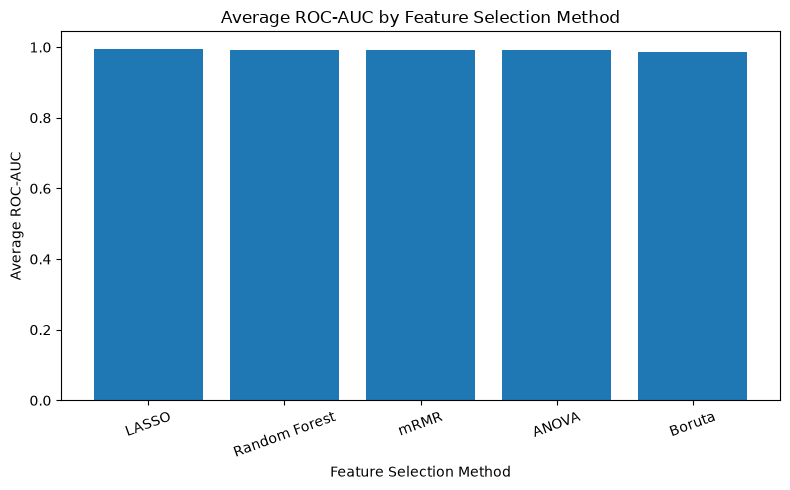

In [76]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_summary.index,
    feature_summary["ROC-AUC"]
)

plt.title("Average ROC-AUC by Feature Selection Method")

plt.xlabel("Feature Selection Method")

plt.ylabel("Average ROC-AUC")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

### Interpretation

The bar chart compares the average ROC-AUC achieved by each feature selection method across all classification models.

Methods with higher average ROC-AUC demonstrate better overall discriminative performance.

This visualization provides an intuitive comparison of the robustness of different feature selection techniques.

## 5.9.2 Average ROC-AUC by Classification Model

The predictive performance of the evaluated classification models is compared by averaging ROC-AUC across all feature selection methods.

This analysis helps identify the classifier that consistently provides the strongest predictive performance.

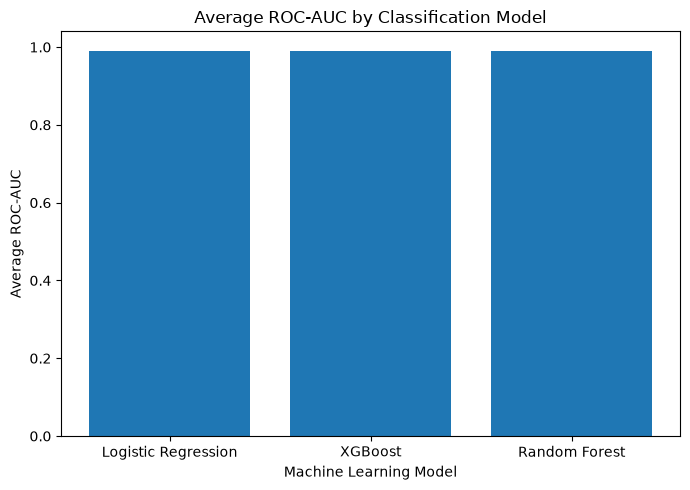

In [77]:
plt.figure(figsize=(7,5))

plt.bar(
    model_summary.index,
    model_summary["ROC-AUC"]
)

plt.title("Average ROC-AUC by Classification Model")

plt.xlabel("Machine Learning Model")

plt.ylabel("Average ROC-AUC")

plt.tight_layout()

plt.show()

### Interpretation

The chart summarizes the average ROC-AUC achieved by each classification algorithm.

Models with higher ROC-AUC demonstrate stronger predictive capability across different feature subsets.

This comparison helps determine whether classifier choice has a significant influence on prediction performance.

## 5.9.3 Heatmap of ROC-AUC Scores

The heatmap visualizes the ROC-AUC achieved by every combination of feature selection method and machine learning model.

Darker values indicate better predictive performance.

This figure allows rapid identification of the strongest feature selection–model combinations.

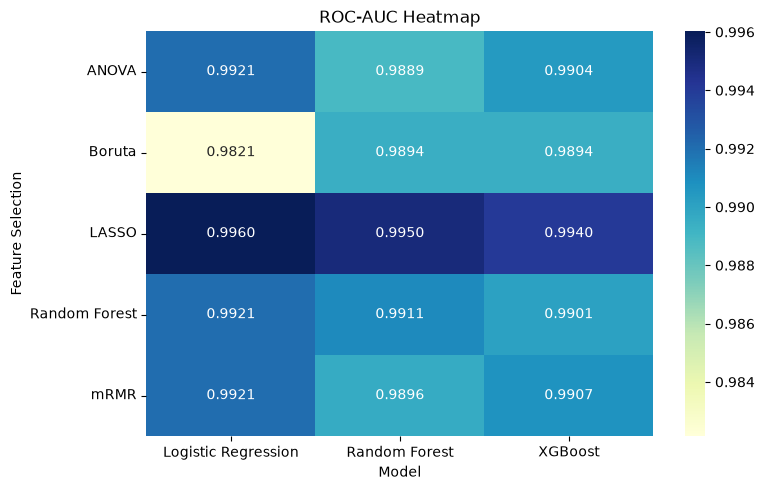

In [78]:
heatmap_df = results_df.pivot(
    index="Feature Selection",
    columns="Model",
    values="ROC-AUC"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f"
)

plt.title("ROC-AUC Heatmap")

plt.tight_layout()

plt.show()

### Interpretation

Each cell represents the ROC-AUC achieved by a particular feature selection–model combination.

Higher values indicate stronger predictive performance.

The heatmap enables easy identification of combinations that consistently outperform others.

## 5.9.4 Ranking of All Experiments

The experiments are ranked according to ROC-AUC.

This visualization highlights the strongest feature selection–classifier combinations evaluated in the benchmark.

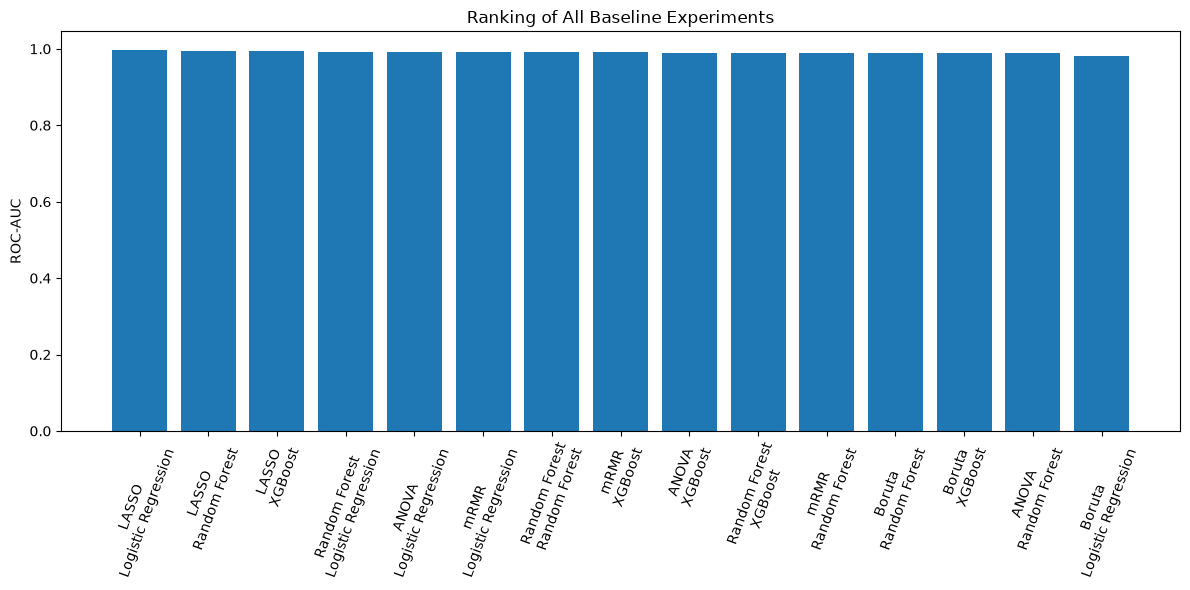

In [79]:
ranking_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

labels = (
    ranking_df["Feature Selection"]
    + "\n"
    + ranking_df["Model"]
)

plt.figure(figsize=(12,6))

plt.bar(
    labels,
    ranking_df["ROC-AUC"]
)

plt.title("Ranking of All Baseline Experiments")

plt.ylabel("ROC-AUC")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

### Interpretation

The experiments are ranked according to ROC-AUC.

This figure highlights the best-performing feature selection–model combinations and provides an overall ranking of the evaluated approaches.

The highest-ranked experiment serves as the baseline for subsequent validation using cross-validation, feature stability analysis, and the Clinical Relevance Layer.

# 6. Stratified 10-Fold Cross Validation

## Why Cross Validation?

The baseline experiments evaluate predictive performance using a single train-test split.

Although useful, the results may depend on how the dataset was partitioned.

To obtain a more reliable estimate of model performance, Stratified 10-Fold Cross Validation is performed.

In Stratified Cross Validation:

- The dataset is divided into 10 folds.
- Each fold preserves the original class distribution.
- Nine folds are used for training.
- One fold is used for testing.
- The process is repeated until every fold has been used once for testing.

The average performance across all folds provides a more robust estimate of model generalization.

In [80]:
# imports

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

In [81]:
# Cross Validator

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

### Cross Validation Strategy

A Stratified 10-Fold Cross Validation strategy is used.

Stratification ensures that each fold contains approximately the same proportion of class labels as the complete dataset.

Random shuffling improves the robustness of the partitioning process while maintaining reproducibility through a fixed random seed.

In [82]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

## 6.2 Cross Validation: Logistic Regression with ANOVA Features

Before automating cross-validation for all feature selection methods and classification models, the workflow is demonstrated using a single experiment.

In this example, Logistic Regression is evaluated using the feature subset selected by the ANOVA method.

Stratified 10-Fold Cross Validation is applied to estimate the model's predictive performance across multiple data partitions.

The mean and standard deviation of each evaluation metric are reported to assess both predictive accuracy and consistency.

In [83]:
# Select feature subset
X_cv = X_train_scaled[anova_features]

# Select model
model_cv = LogisticRegression(
    random_state=42
)

In [84]:
# Run cross-validation

cv_results = cross_validate(
    estimator=model_cv,
    X=X_cv,
    y=y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [85]:
# Inspect raw results

cv_results.keys()

dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc'])

In [86]:
# Display all fold scores

pd.DataFrame(cv_results)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,0.020190,0.023293,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.008852,0.017011,0.891304,0.900000,0.931034,0.915254,0.939148
2,0.007432,0.016047,0.956522,1.000000,0.931034,0.964286,0.997972
3,0.008320,0.017387,0.978261,0.966667,1.000000,0.983051,0.967546
4,0.007291,0.015556,0.934783,0.906250,1.000000,0.950820,0.989858
5,0.008476,0.015433,0.933333,1.000000,0.892857,0.943396,0.997899
6,0.007572,0.014255,0.933333,0.931034,0.964286,0.947368,0.983193
7,0.008435,0.020680,0.933333,0.931034,0.964286,0.947368,0.993697
8,0.014502,0.022120,1.000000,1.000000,1.000000,1.000000,1.000000
9,0.008532,0.019288,0.955556,0.964286,0.964286,0.964286,0.993697


In [87]:
# Computing mean and standard deviation for each metric

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std Dev": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary = cv_summary.round(4)

cv_summary

,Metric,Mean,Std Dev
0,Accuracy,0.9516,0.0322
1,Precision,0.9599,0.0382
2,Recall,0.9648,0.0352
3,F1 Score,0.9616,0.0253
4,ROC-AUC,0.9863,0.0183


### Interpretation

Stratified 10-Fold Cross Validation provides a more reliable estimate of model performance by evaluating the classifier across multiple training and testing partitions.

The mean values represent the average predictive performance across all folds, while the standard deviation reflects the consistency of the model.

Lower standard deviation indicates more stable and reliable performance, whereas higher variability suggests that the model is more sensitive to changes in the training data.

## 6.3 Research-Grade Cross Validation Pipeline

To prevent data leakage, feature selection must be performed **inside each training fold** rather than before cross-validation.

For each fold, the workflow is:

1. Split the data into training and validation folds.
2. Perform feature selection using only the training fold.
3. Transform both training and validation data using the selected features.
4. Train the classifier.
5. Evaluate on the validation fold.

This process is repeated for all folds, ensuring an unbiased estimate of predictive performance.

In [88]:
# import clone

from sklearn.base import clone

In [89]:
# Creating an empty function

def cross_validate_pipeline(
    X,
    y,
    feature_selector,
    model,
    cv
):
    """
    Perform research-grade cross validation.
    """

In [90]:
# Create storage:

cv_scores = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "ROC-AUC": []
}

In [91]:
# Start cross-validation loop

for train_idx, test_idx in cv.split(X, y):

    X_train_fold = X.iloc[train_idx]

    X_test_fold = X.iloc[test_idx]

    y_train_fold = y.iloc[train_idx]

    y_test_fold = y.iloc[test_idx]

In [93]:
    # ANOVA Feature Selection

selector = SelectKBest(
        score_func=f_classif,
        k=10
    )

X_train_selected = selector.fit_transform(
        X_train_fold,
        y_train_fold
    )

X_test_selected = selector.transform(
        X_test_fold
    )

In [95]:
# Training the Logistic Regression model

model = LogisticRegression(
        random_state=42
    )

model.fit(
        X_train_selected,
        y_train_fold
    )

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [97]:
# Predictions

y_pred = model.predict(
        X_test_selected
    )

y_prob = model.predict_proba(
        X_test_selected
    )[:, 1]

In [98]:
# Store the  metrics

cv_scores["Accuracy"].append(
        accuracy_score(y_test_fold, y_pred)
    )

cv_scores["Precision"].append(
        precision_score(y_test_fold, y_pred)
    )

cv_scores["Recall"].append(
        recall_score(y_test_fold, y_pred)
    )

cv_scores["F1"].append(
        f1_score(y_test_fold, y_pred)
    )

cv_scores["ROC-AUC"].append(
        roc_auc_score(y_test_fold, y_prob)
    )


In [99]:
cv_summary = pd.DataFrame({

    "Metric": cv_scores.keys(),

    "Mean": [
        np.mean(v)
        for v in cv_scores.values()
    ],

    "Std Dev": [
        np.std(v)
        for v in cv_scores.values()
    ]

})

cv_summary.round(4)

,Metric,Mean,Std Dev
0,Accuracy,0.9821,0.0
1,Precision,1.0000,0.0
2,Recall,0.9714,0.0
3,F1,0.9855,0.0
4,ROC-AUC,0.9986,0.0


## 6.4 Automated Stratified 10-Fold Cross Validation

After understanding the cross-validation workflow, the process is automated for all feature selection methods and classification models.

For each experiment:

1. The selected feature subset is used.
2. Stratified 10-Fold Cross Validation is performed.
3. Performance metrics are calculated.
4. The mean and standard deviation of each metric are stored.

This provides a more robust estimate of model performance than a single train-test split.

In [100]:
from sklearn.model_selection import cross_validate

# Evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [101]:
# Run cross Validation for all experiments

cv_results = []

for fs_method, (X_train_fs, X_test_fs) in feature_sets.items():

    for model_name, model in models.items():

        scores = cross_validate(
            estimator=model,
            X=X_train_fs,
            y=y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )

        cv_results.append({

            "Feature Selection": fs_method,
            "Model": model_name,

            "Accuracy Mean": scores["test_accuracy"].mean(),
            "Accuracy Std": scores["test_accuracy"].std(),

            "Precision Mean": scores["test_precision"].mean(),
            "Precision Std": scores["test_precision"].std(),

            "Recall Mean": scores["test_recall"].mean(),
            "Recall Std": scores["test_recall"].std(),

            "F1 Mean": scores["test_f1"].mean(),
            "F1 Std": scores["test_f1"].std(),

            "ROC-AUC Mean": scores["test_roc_auc"].mean(),
            "ROC-AUC Std": scores["test_roc_auc"].std()

        })

print("Cross Validation completed successfully!")

Cross Validation completed successfully!


In [102]:
# Convert to DataFrame

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.round(4)

cv_results_df

,Feature Selection,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,ANOVA,Logistic Regression,0.9516,0.0322,0.9599,0.0382,0.9648,0.0352,0.9616,0.0253,0.9863,0.0183
1,ANOVA,Random Forest,0.9407,0.0353,0.9530,0.0397,0.9543,0.0420,0.9527,0.0281,0.9839,0.0187
2,ANOVA,XGBoost,0.9386,0.0376,0.9506,0.0463,0.9543,0.0422,0.9512,0.0296,0.9766,0.0265
3,mRMR,Logistic Regression,0.9516,0.0322,0.9599,0.0382,0.9648,0.0352,0.9616,0.0253,0.9863,0.0183
4,mRMR,Random Forest,0.9407,0.0380,0.9531,0.0426,0.9543,0.0420,0.9527,0.0302,0.9835,0.0198
5,mRMR,XGBoost,0.9363,0.0285,0.9474,0.0429,0.9542,0.0392,0.9495,0.0224,0.9768,0.0257
6,Random Forest,Logistic Regression,0.9516,0.0322,0.9599,0.0382,0.9648,0.0352,0.9616,0.0253,0.9863,0.0183
7,Random Forest,Random Forest,0.9407,0.0380,0.9531,0.0426,0.9543,0.0420,0.9527,0.0302,0.9829,0.0197
8,Random Forest,XGBoost,0.9319,0.0331,0.9439,0.0457,0.9507,0.0396,0.9460,0.0258,0.9768,0.0259
9,LASSO,Logistic Regression,0.9714,0.0262,0.9768,0.0255,0.9787,0.0428,0.9769,0.0222,0.9945,0.0092


In [103]:
# Saving the results to CSV

cv_results_df.to_csv(
    "results/metrics/cross_validation_results.csv",
    index=False
)

print("Cross-validation results saved successfully!")

Cross-validation results saved successfully!


### Interpretation

The table summarizes the average performance of each feature selection–model combination using Stratified 10-Fold Cross Validation.

For each evaluation metric, the mean represents the average performance across the ten folds, while the standard deviation indicates the variability of the model.

Lower standard deviation suggests more consistent performance across different data partitions.

# 7. Jaccard Stability Analysis

Feature stability measures how consistently different feature selection methods identify important features.

The Jaccard Similarity Coefficient is used to compare the overlap between two feature sets.

A value of:

- 1 indicates identical feature sets.
- 0 indicates no common features.

Higher Jaccard similarity suggests greater stability and agreement between feature selection methods.

In [104]:
from sklearn.metrics import jaccard_score

In [107]:
# Creating a dictionary for selected features

selected_features = {
    "ANOVA": set(anova_features),
    "mRMR": set(mrmr_features),
    "Random Forest": set(rf_features),
    "LASSO": set(lasso_features),
    "Boruta": set(boruta_features)
}

In [108]:
# Calculating Jaccard Similarity Matrix

methods = list(selected_features.keys())

jaccard_matrix = pd.DataFrame(
    index=methods,
    columns=methods
)

for m1 in methods:
    for m2 in methods:

        intersection = len(
            selected_features[m1] &
            selected_features[m2]
        )

        union = len(
            selected_features[m1] |
            selected_features[m2]
        )

        similarity = intersection / union

        jaccard_matrix.loc[m1, m2] = round(similarity, 2)

jaccard_matrix

,ANOVA,mRMR,Random Forest,LASSO,Boruta
ANOVA,1.0,1.0,1.0,0.18,0.33
mRMR,1.0,1.0,1.0,0.18,0.33
Random Forest,1.0,1.0,1.0,0.18,0.33
LASSO,0.18,0.18,0.18,1.0,0.25
Boruta,0.33,0.33,0.33,0.25,1.0


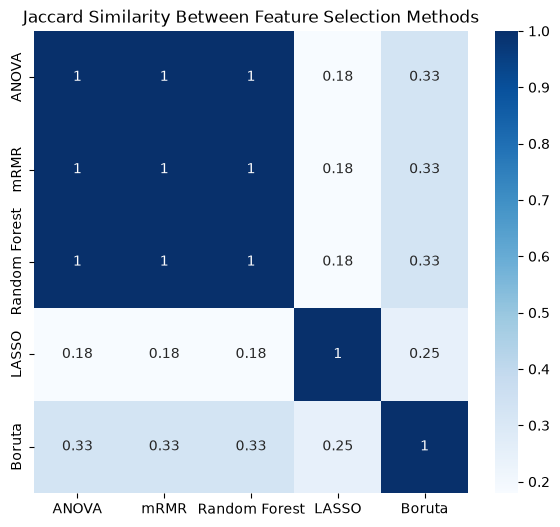

In [109]:
# Visualization

plt.figure(figsize=(7,6))

sns.heatmap(
    jaccard_matrix.astype(float),
    annot=True,
    cmap="Blues"
)

plt.title("Jaccard Similarity Between Feature Selection Methods")

plt.show()

### Interpretation

The Jaccard similarity matrix illustrates the agreement between feature selection methods.

Higher values indicate that two methods selected many of the same features, while lower values indicate greater differences.

This analysis helps evaluate the stability and consistency of feature selection techniques.

# 8. Clinical Relevance Layer

Predictive performance alone is not sufficient in healthcare.

Selected features should also be clinically meaningful.

For demonstration purposes, clinically relevant features were identified based on established breast cancer diagnostic knowledge.

In [116]:
# Creating a list of clinically important features.

clinical_features = [

    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "worst radius",
    "worst perimeter",
    "worst area",
    "worst compactness",
    "worst concavity",
    "worst concave points"

]

In [117]:
# Compare every feature selection method.

clinical_results = []

for method, features in selected_features.items():

    overlap = len(
        set(features) &
        set(clinical_features)
    )

    percentage = overlap / len(clinical_features) * 100

    clinical_results.append({

        "Feature Selection": method,

        "Clinical Features Selected": overlap,

        "Clinical Relevance (%)": round(percentage,2)

    })

clinical_df = pd.DataFrame(clinical_results)

clinical_df

,Feature Selection,Clinical Features Selected,Clinical Relevance (%)
0,ANOVA,10,76.92
1,mRMR,10,76.92
2,Random Forest,10,76.92
3,LASSO,4,30.77
4,Boruta,7,53.85


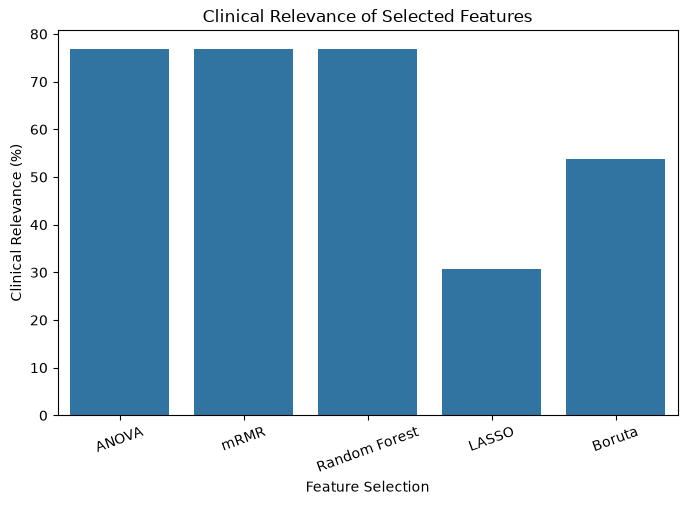

In [118]:
# Visualization

plt.figure(figsize=(8,5))

sns.barplot(
    data=clinical_df,
    x="Feature Selection",
    y="Clinical Relevance (%)"
)

plt.title("Clinical Relevance of Selected Features")

plt.xticks(rotation=20)

plt.show()

### Interpretation

The Clinical Relevance Layer evaluates how well each feature selection method captures clinically meaningful variables.

Methods with higher percentages demonstrate better alignment with established clinical knowledge.

# 9. Final Comparison

The final comparison combines predictive performance with feature stability and clinical relevance.

This provides a more comprehensive evaluation of feature selection methods.

In [119]:
# Merge the summaries

final_results = feature_summary.merge(

    clinical_df,

    on="Feature Selection"

)

final_results

,Feature Selection,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Clinical Features Selected,Clinical Relevance (%)
0,LASSO,0.9678,0.9768,0.9722,0.9745,0.9950,4,30.77
1,Random Forest,0.9561,0.9633,0.9676,0.9653,0.9911,10,76.92
2,mRMR,0.9532,0.9631,0.9630,0.9629,0.9908,10,76.92
3,ANOVA,0.9561,0.9633,0.9676,0.9653,0.9905,10,76.92
4,Boruta,0.9298,0.9615,0.9259,0.9432,0.9870,7,53.85


In [120]:
# Sort by ROC-AUC

final_results = final_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

final_results

,Feature Selection,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Clinical Features Selected,Clinical Relevance (%)
0,LASSO,0.9678,0.9768,0.9722,0.9745,0.9950,4,30.77
1,Random Forest,0.9561,0.9633,0.9676,0.9653,0.9911,10,76.92
2,mRMR,0.9532,0.9631,0.9630,0.9629,0.9908,10,76.92
3,ANOVA,0.9561,0.9633,0.9676,0.9653,0.9905,10,76.92
4,Boruta,0.9298,0.9615,0.9259,0.9432,0.9870,7,53.85


In [121]:
# Save to csv

final_results.to_csv(
    "results/metrics/final_comparison.csv",
    index=False
)

print("Final comparison saved successfully!")


Final comparison saved successfully!


# Conclusion

This prototype benchmark compared five feature selection methods using multiple machine learning models for breast cancer prediction.

Evaluation included:

- Baseline performance
- Stratified 10-Fold Cross Validation
- Feature stability using Jaccard Similarity
- Clinical Relevance Layer

The notebook demonstrates a reproducible workflow for comparing feature selection techniques in clinical machine learning and serves as a foundation for future research using larger clinical datasets.